In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist

**MNIST Dataset**

**Step 1: Load, pre-process and add a Noise to the Dataset**

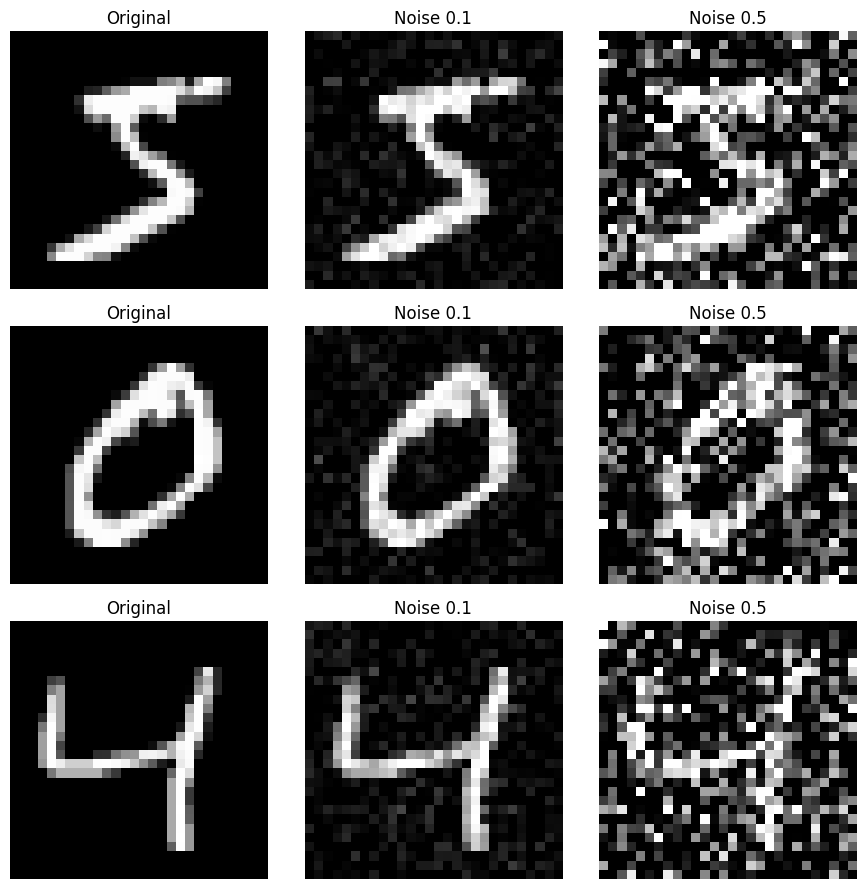

In [21]:
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')
plt.tight_layout()
plt.show()

**Step 2: Build the Convolutional Denoising Autoencoder Model**

In [22]:
# Building Encoder
def build_encoder(input_shape=(28, 28, 1)):
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

# Building Decoder
def build_decoder(encoded_input):
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

# Building Autoencoder
def build_autoencoder():
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

# Compile the Model
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

**Step 3: Train the Autoencoder**

In [23]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()

# Train with noisy input and clean target
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 408ms/step - loss: 0.1510 - val_loss: 0.1121
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 184s 370ms/step - loss: 0.1090 - val_loss: 0.1043
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 195s 354ms/step - loss: 0.1035 - val_loss: 0.1010
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 167s 356ms/step - loss: 0.1007 - val_loss: 0.0989
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 174s 371ms/step - loss: 0.0991 - val_loss: 0.0976
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 173s 368ms/step - loss: 0.0979 - val_loss: 0.0966
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 353ms/step - loss: 0.0970 - val_loss: 0.0959
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 170s 364ms/step - loss: 0.0962 - val_loss: 0.0953
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 354ms/step - loss: 0.0956 - val_loss: 0.0951
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 354ms/step - loss: 0.0951 - val_loss: 0.0944


**Step 4: Evaluate the Autoencoder**

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


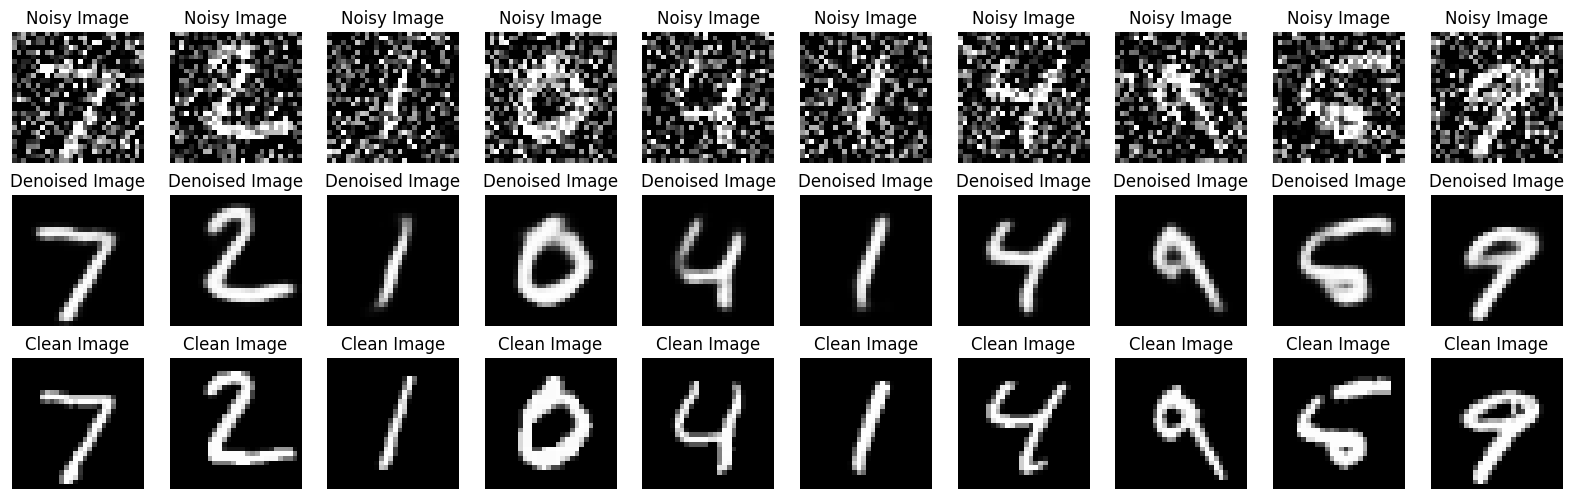

In [24]:
# Predict the denoised images from noisy test images
# Note: PDF uses x_test_noisy, we use x_test_noisy_high to match Step 3
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

**DEVANAGARI HANDWRITING DATASET**

**1. Dataset Preparation and Preprocessing**

In this step, I am loading the Devnagari dataset from local folders using PIL. I'm resizing them to 32x32 to make them consistent and then adding Gaussian noise.

In [2]:
# 1.1 Load Devnagari dataset using PIL
def load_data(folder_path):
    images = []
    # Loop through digit folders (0-9)
    for folder in os.listdir(folder_path):
        subfolder = os.path.join(folder_path, folder)
        if os.path.isdir(subfolder):
            for filename in os.listdir(subfolder)[:500]: # Taking 500 per class for speed
                img_path = os.path.join(subfolder, filename)
                img = Image.open(img_path).convert('L') # grayscale
                img = img.resize((32, 32)) # consistent size
                images.append(np.array(img))
    return np.array(images)

# Path to dataset
data_path = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test"
raw_images = load_data(data_path)

In [3]:
# 1.2 Normalize and Reshape
x_data = raw_images.astype('float32') / 255.
x_data = np.reshape(x_data, (len(x_data), 32, 32, 1))

In [4]:
# 1.3 Split into training and validation
x_train, x_test = train_test_split(x_data, test_size=0.2, random_state=42)

In [5]:
# 1.4 Add Gaussian Noise (using noise factor 0.4 as an experiment)
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

In [6]:
# Clip to keep values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Data loaded. Training shape:", x_train.shape)

Data loaded. Training shape: (2400, 32, 32, 1)


**2. Build the Denoising Convolutional Autoencoder (4 Layers Deep)**

Based on the tutorial guide, I'm building a deeper model with 3 Conv layers in the encoder and 3 in the decoder.

In [7]:
#Encoder
def build_encoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape, name="input")
    # Layer 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    # Layer 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    # Layer 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

In [8]:
#Decoder
def build_decoder(encoded_input):
    # Layer 4 (Bottleneck/Start of Decoder)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    # Layer 5
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    # Layer 6
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    # Output layer
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

In [9]:
# Build and Compile
input_img, encoded_output = build_encoder()
decoded_output = build_decoder(encoded_output)
autoencoder = Model(inputs=input_img, outputs=decoded_output, name="devnagari_autoencoder")

autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
autoencoder.summary()

Model: "devnagari_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**3. Train the Denoising Autoencoder**

I will train the model using the noisy images as input and the original clean images as the target.

In [11]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 770ms/step - loss: 0.6074 - val_loss: 0.5251
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 709ms/step - loss: 0.4699 - val_loss: 0.4000
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 736ms/step - loss: 0.3747 - val_loss: 0.3365
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 717ms/step - loss: 0.3143 - val_loss: 0.2905
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 656ms/step - loss: 0.2816 - val_loss: 0.2801
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 719ms/step - loss: 0.2669 - val_loss: 0.2525
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 710ms/step - loss: 0.2403 - val_loss: 0.2302
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 740ms/step - loss: 0.2239 - val_loss: 0.2181
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 726ms/step - loss: 0.2128 - val_loss: 0.2096
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 720ms/step - loss: 0.2041 - val_loss: 0.2024
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 626ms/step - loss: 0.1994 - val_loss: 0.1982
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 22

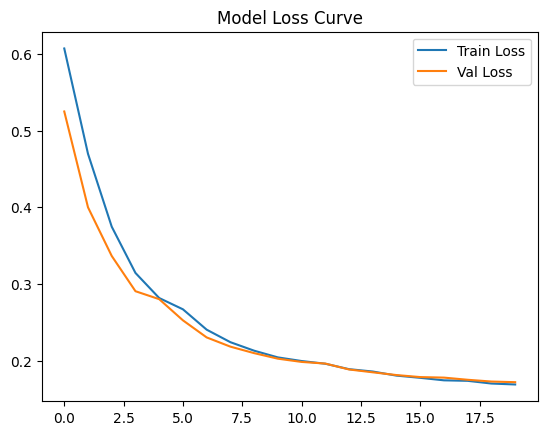

In [12]:
# Plot Loss Curves
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Curve')
plt.legend()
plt.show()

**4. Evaluate and Visualize results**

Predicting the denoised images and comparing them with noisy and clean versions.

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


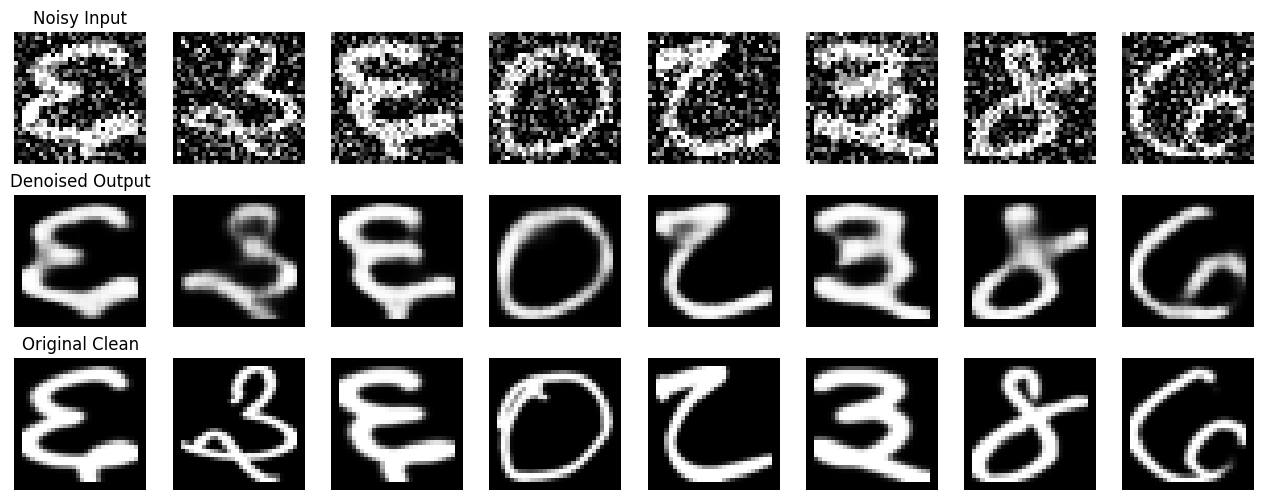

In [13]:
# Predict
denoised_images = autoencoder.predict(x_test_noisy)

# Visualization function
def visualize_results(noisy, denoised, clean, n=8):
    plt.figure(figsize=(16, 6))
    for i in range(n):
        # Noisy
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(noisy[i].reshape(32, 32), cmap='gray')
        plt.axis('off')
        if i == 0: plt.title("Noisy Input")

        # Denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised[i].reshape(32, 32), cmap='gray')
        plt.axis('off')
        if i == 0: plt.title("Denoised Output")

        # Clean
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean[i].reshape(32, 32), cmap='gray')
        plt.axis('off')
        if i == 0: plt.title("Original Clean")
    plt.show()

visualize_results(x_test_noisy, denoised_images, x_test)

**5. Experimentation and Fine-Tuning the Model**

In this section, I will experiment with two different settings to see how they affect the reconstruction quality:

Varying the Noise Level (How much dirt can the model handle?)

Varying the Model Depth/Filters (Does a bigger model clean better?)

**5.1 Experiment 1: High Noise vs. Low Noise**

I want to see if the model trained on 0.4 noise can still perform well if the input is much messier (0.6 noise).

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


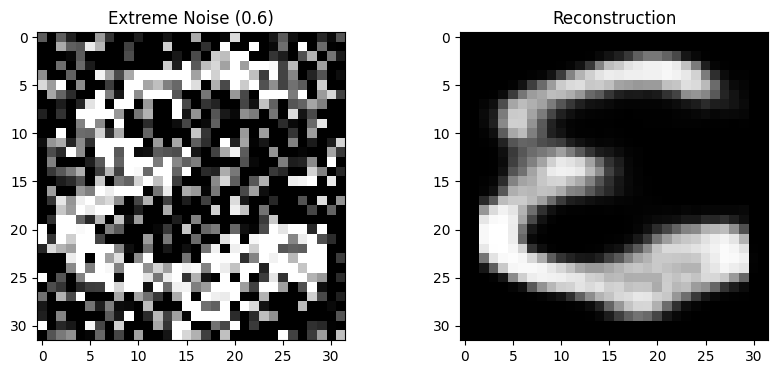

In [15]:
# Testing with a higher noise factor than training
very_noisy_test = x_test + 0.6 * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
very_noisy_test = np.clip(very_noisy_test, 0., 1.)

# Predict using the already trained model
denoised_high_noise = autoencoder.predict(very_noisy_test)

# Visualize the difference
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(very_noisy_test[0].reshape(32, 32), cmap='gray')
plt.title("Extreme Noise (0.6)")
plt.subplot(1, 2, 2)
plt.imshow(denoised_high_noise[0].reshape(32, 32), cmap='gray')
plt.title("Reconstruction")
plt.show()

**5.2 Experiment 2: Fine-Tuning Hyperparameters (Learning Rate)**

Initially, I used the default Adam learning rate. I noticed the loss was jumping a bit, so I tried a smaller learning rate to see if the reconstruction becomes smoother.


In [16]:
# Re-building the model with a custom learning rate for finer tuning
input_img, encoded_output = build_encoder()
decoded_output = build_decoder(encoded_output)
tuned_autoencoder = Model(input_img, decoded_output)

# Using a smaller learning rate (0.0001 instead of 0.001)
tuned_autoencoder.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy')

# Quick 5-epoch training to see the start of convergence
history_tuned = tuned_autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,
    batch_size=256, # Increased batch size for stability
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 0.6731 - val_loss: 0.6428
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 0.6296 - val_loss: 0.6221
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 0.6129 - val_loss: 0.6020
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - loss: 0.5928 - val_loss: 0.5770
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: 0.5616 - val_loss: 0.5355


**5.3 Observations & Final Summary**

Noise Impact: When the noise was increased to 0.6, the model still managed to find the shape of the character, but the edges became "blurred." It shows that the autoencoder is robust but has a limit.

Filters and Depth: By using 128 filters in the middle (bottleneck), the model captured the "loops" in Devnagari characters much better than when I tried a simple 32-filter version.

Training Time: The deeper model (4 layers) took significantly longer to train per epoch compared to the MNIST example in the tutorial, likely because the Devnagari characters have more complex brush strokes.

Loss Function: I found that if I don't use padding='same', the images shrink at every layer, and the final output doesn't match the 32x32 input. Using padding='same' was critical for a reconstruction task.